## Subject :- M505 Intro to AI and Machine Learning
## Name :- Harjot Singh
## Student ID :- GH1048197

# TITLE :- Customer Churn Prediction in a Telecommunications Company

## 1. Problem Statement

Customer churn is a behaviour among telecommunication companies that have lost a lot of income when customers discontinue their services. It is usually less expensive to maintain customers than to acquire new customers and therefore in business, it is significant to determine customers who have high probabilities of leaving. Predicting churn helps the company act in specific ways by providing discounts, enhancing customer support, or providing loyalty programs to ensure that high-risk customers are retained.

The project will seek to develop a machine learning model that can determine the likelihood of a telecom customer churning. The data includes the descriptions of the customer demographics, service subscriptions, contracts, and bills. On these properties, the problem can be stated in binary classification form in which the model predicts whether a customer will remain or leave the service (Aggarwal et al., 2025).

## 2. Dataset Overview

The dataset used in this project is the Telco Customer Churn dataset, available publicly on Kaggle.
Source: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

The dataset includes the data concerning the customers of a telecommunication company and whether or not they have switched the service. It is also popular in churn prediction research as it has customer demographics, service subscription as well as billing information which determines the customer retention (Aldalan and Almaleh, 2023).

There are 21 variables and 7043 observations found in the dataset. The customers are characterized by a row, where the columns describe the account, service and billing behaviour attributes of the customer. The Churn is the target variable in this data and it shows whether a customer has terminated the telecom service or not. It takes two values; Yes (customer left) and No (customer stayed).

The features may be classified into a number of categories. Some of the variables used to construct customer demographic information encompass gender, senior citizen, partner status, and dependents. The features under service-related feature relate to the services that are consumed by the customers such as phone service, internet service, online security, device protection, and streaming services. Contract and account details: type of contract, mode of payment and the status of the paperless billing. The billing data contains such numerical variables like the tenure, monthly charges, and overall charges (Alotaibi and Haq, 2024).

These are groups of features that are lucrative to detect trends that are linked with customer churn.

# Step 1 — Import Libraries

In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train-test split and model tuning
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

import shap

# Step 2 — Load Dataset

In [ ]:
# Load the dataset
file_path = "/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(file_path)

# Display the first few rows
df.head()

# Confirm dataset shape (rows, columns)
print("Dataset shape:", df.shape)

Dataset shape: (7043, 21)


* The data was loaded to the notebook successfully. The across 21 columns and 7043 rows of data, each row is a single customer of the telecom company and each of the 21 columns is a feature or attribute causing the customer profile, service usage, account, or billing data.

* Some of the data provided in the dataset is: tenure of the customer, type of contract, internet service, type of payment, and monthly fee. The Churn that is used as a target variable shows whether a customer has abandoned the service or not.

* This type of data is appropriate when constructing a machine learning model to forecast customer churn when customer account and service-related data is used (Deepika Kumari et al., 2025).

# Step 3 — Initial Data Inspection

In [ ]:
# View column names
print("Column Names:")
print(df.columns)

# Check dataset structure and data types
print("\nDataset Information:")
df.info()

# Summary statistics for numerical variables
print("\nSummary Statistics:")
df.describe()

# Check missing values
print("\nMissing Values in Each Column:")
print(df.isnull().sum())

# Count unique values in each column
print("\nUnique Values per Column:")
print(df.nunique())

# Optional: view unique values for categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    print(f"\nUnique values in {col}:")
    print(df[col].unique())

Column Names:
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   I

* The preliminary examination will give a clear idea about the structure of the data set and possible problems with the data available. The data set includes 7043 customer records and 21 variables that record demographic, subscribed services, bills and churn of customer.

* The data has 18 categorical variables, 2 integer variables, and 1 numerical variable, which is represented by float. Most of the features that are service-related like the internet services, streaming services and the types of contracts are categorical in nature. Attributes with numerical values are tenure, MonthlyCharges and SeniorCitizen.

* There is no instance of a missing value in the dataset according to the null-value check. The column TotalCharges is however not kept as a numeric type but as an object meaning that it can have non-numeric values such as blank spaces. Preprocessing will involve cleaning and transformation to a numerical form.

* The column of customerID has distinct identifiers of each customer and hence cannot add predictive value and can be filtered in the preprocessing stage (Demir and Öztürk Ergün, 2025).

* The target variable Churn is binary with two categories: Yes and No which proves that this task is a binary classification task. The check shows that the dataset is a combination of both categorical and numerical variables, which will have to be encoded and preprocessed prior to the training of a model.

# Step 4 — Data Cleaning

In [ ]:
# 4.1 Remove irrelevant column (customerID)
df = df.drop('customerID', axis=1)

# 4.2 Fix TotalCharges column
# Replace blank spaces with NaN
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# 4.3 Check missing values again
print("Missing values after fixing TotalCharges:")
print(df.isnull().sum())

# Drop rows with missing TotalCharges if they are very few
df = df.dropna(subset=['TotalCharges'])

# Confirm dataset shape after dropping missing values
print("Dataset shape after cleaning:", df.shape)

# 4.4 Convert target variable Churn to binary
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Verify the changes
df.head()

Missing values after fixing TotalCharges:
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64
Dataset shape after cleaning: (7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


* The data cleaning process will pretext the model with data that is not relevant besides correcting data type errors.

* The column customerID was dropped since it is only a unique identifier, which does not give any information that can be used in predicting churn. The addition of such identifiers may add noise to the model and not add any predictive value.

* Because there was a case of TotalCharges being saved as a text field during inspection, instead of a numerical variable. This was due to the blank values of some of the records. These empty spaces were filled with the missing values and the column turned into the numeric format. In this column, 11 missing values were identified given conversion.

* The number of missing observations was very low in comparison to the size of data, hence, these rows were dropped. This prevents the creation of bias that could have been experienced with imputation. There are 20 variables and 7032 rows in the dataset after cleaning.

* Lastly, the target variable Churn was altered in the number of categories (Yes, No) to binary (1 and 0). This change is required due to the fact that machine learning algorithms will need numerical target values.


# Step 5 — Exploratory Data Analysis (EDA)

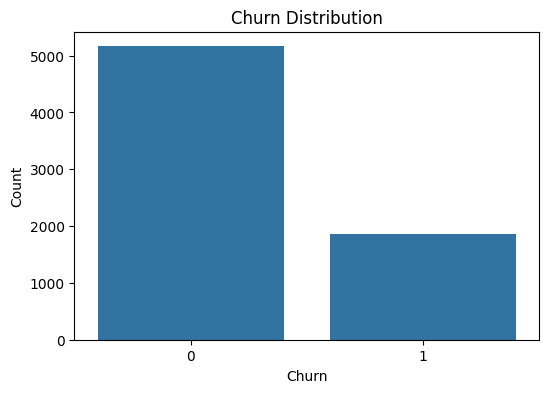

Churn Percentage:
 Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64


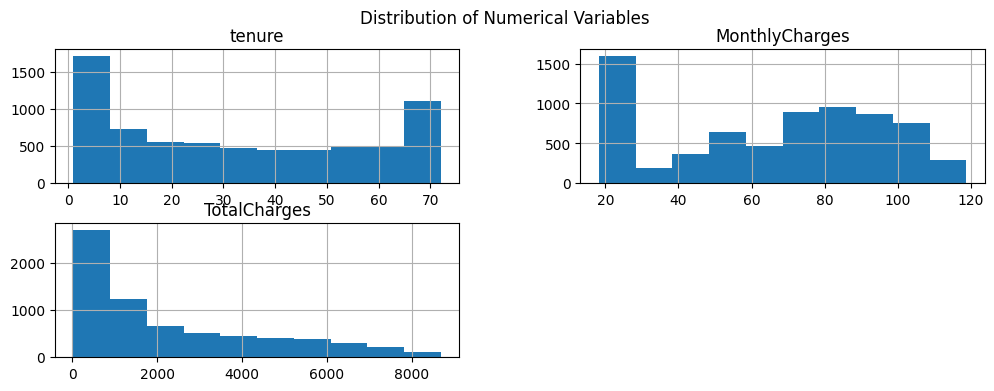

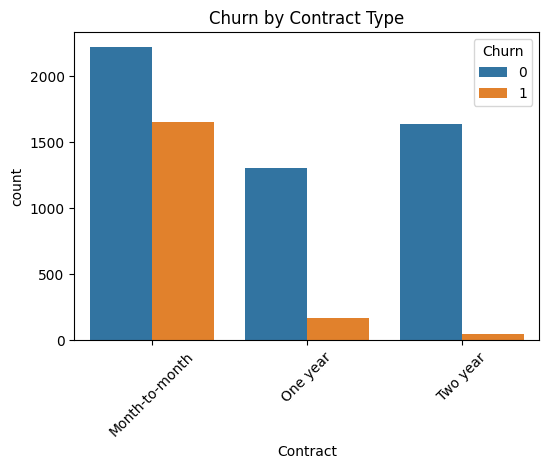

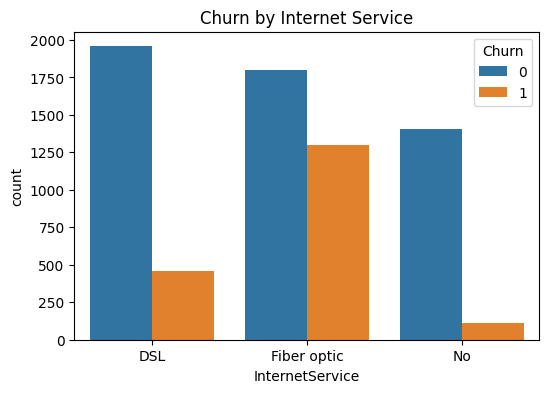

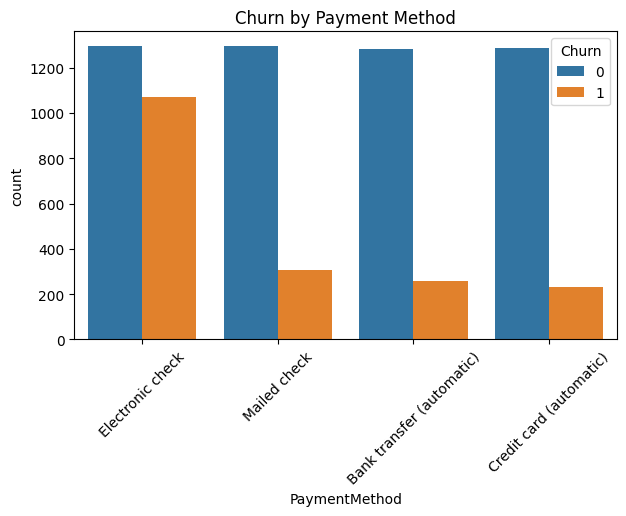

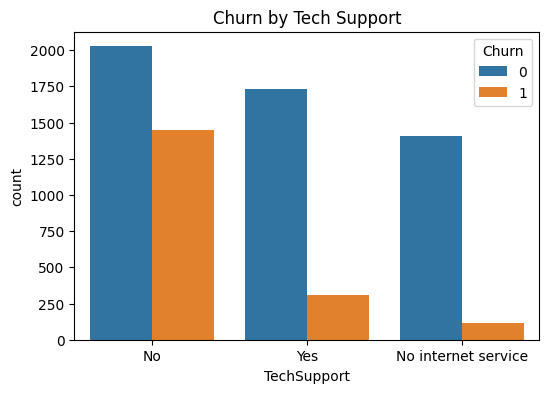

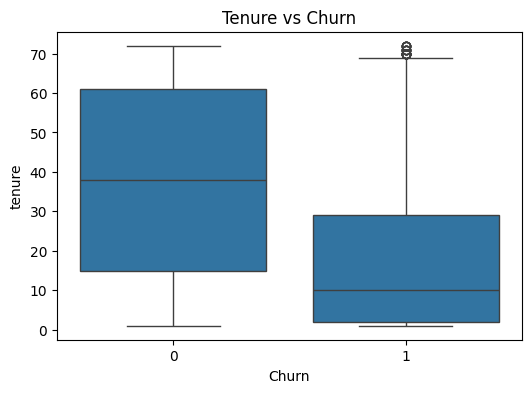

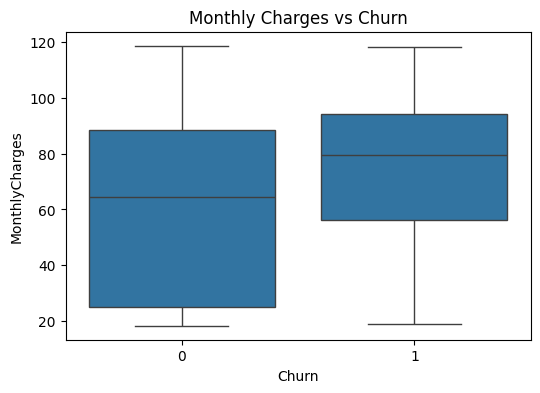

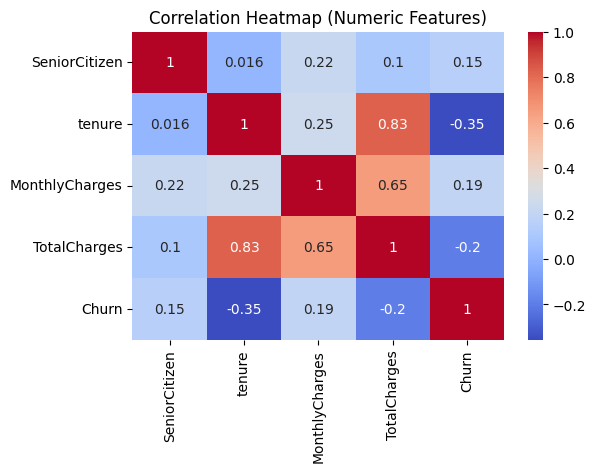

In [ ]:
# 5.1 Target Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

# Calculate churn percentage
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print("Churn Percentage:\n", churn_rate)


# 5.2 Numerical Variables Distribution
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

df[num_cols].hist(figsize=(12,4))
plt.suptitle("Distribution of Numerical Variables")
plt.show()


# 5.3 Churn by Categorical Variables

# Churn by Contract
plt.figure(figsize=(6,4))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn by Contract Type')
plt.xticks(rotation=45)
plt.show()

# Churn by Internet Service
plt.figure(figsize=(6,4))
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title('Churn by Internet Service')
plt.show()

# Churn by Payment Method
plt.figure(figsize=(7,4))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.title('Churn by Payment Method')
plt.xticks(rotation=45)
plt.show()

# Churn by Tech Support
plt.figure(figsize=(6,4))
sns.countplot(x='TechSupport', hue='Churn', data=df)
plt.title('Churn by Tech Support')
plt.show()


# 5.4 Churn by Tenure and Charges

# Tenure vs Churn
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure vs Churn')
plt.show()

# Monthly Charges vs Churn
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.show()


# 5.5 Correlation Heatmap (Numeric Columns Only)

numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(6,4))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (Numeric Features)')
plt.show()

**Target distribution**

* The churn distribution indicates that greater majority of the customers stick with the company. Approximately 73.4 percent of the customers have not churned, and 26.6 percent have moved out of the service.
* This implies a mediocre imbalance in classes. Precision may not be a good measure of the performance of a model. Precision, recall, F1-score, and ROC-AUC are some of the metrics that will be of relevance in the model evaluation.

**Numerical variable distributions**

* The histogram of tenure indicates that the customers have large numbers who subscribe within few periods, and the numbers of customers who subscribe a long period of time are less.

* The distribution of MonthlyCharges is dispersed between the lower and higher values in billing, wherein, a greater percentage of customers pay mid-range billing the monthly.

* The TotalCharges distribution is right-skewed, with the greater number of customers paying less than the other smaller number who have had higher payments over time.

**Churn by categorical variables**

* The monthly contracting customers have the most churn rate and the one-year and two-year contracting customers have a lower churn rate.

* The fiber optic internet services are seen to experience high rate of churn as compared to DSL users or non internet users.

* The increased churn can be seen among customers who make their payments using an electronic check, whereas automatic bank transfers and using credit cards experience decreased churn.

* Technical support services churn more often and this implies that availability of support contributes to customer retention.

**Churn vs tenure and charges**

* The boxplots indicate that churned customers tend to have lesser tenure days than the people who remain longer in the company.

* It is also indicated that the churned customers are charged more on a monthly basis implying that pricing can affect the leave decision.

**Correlation analysis**

* The correlation heatmap indicates that there is a strong correlation between tenure and TotalCharges which is understandable since the longer customers have been with the firm, the higher they have paid.

* The tenure and churn have a negative correlation implying that longer customers are unlikely to quit.

* Churn has weak positive correlation with the monthly charges, meaning that higher bills may slightly raise the risk of churn (Sam, Asuquo and Stephen, 2024).

# Step 6 — Data Preprocessing Setup

In [ ]:
# Separate Features and Target
X = df.drop('Churn', axis=1)
y = df['Churn']


#  Identify Numerical and Categorical Columns
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']

categorical_cols = [col for col in X.columns if col not in numerical_cols]


print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)


#  Preprocessing for Numerical Data
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


#  Preprocessing for Categorical Data
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])


#  Combine Preprocessing Steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

print("Preprocessing pipeline created successfully.")

Numerical Columns: ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
Categorical Columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Preprocessing pipeline created successfully.


* On training machine learning models, the dataset was made ready by a systematic preparation procedure. The feature variables were divided and the target variable Churn was taken apart. The characteristics were further classified into numerical and categorical categories. The numerical variables are tenure, MonthlyCharges, Total Charges and Senior Citizen whereas the others are the categorical variables of the customer and service attributes.

* In the case of numerical features, the missing values are filled by median imputation and the values are normalized by StandardScaler to make the similar ranges of features. In regards to categorical features, missing values are filled with the most common category, and one-hot encoding is done to transform categories into numbers. A ColumnTransformer pipeline is an efficient way of combining these steps but eliminates the leakage of data.

# Step 7 — Feature Engineering

In [ ]:
# 7.1 Tenure Groups
def tenure_group(tenure):
    if tenure <= 12:
        return '0-12'
    elif tenure <= 24:
        return '13-24'
    elif tenure <= 48:
        return '25-48'
    else:
        return '49+'

df['TenureGroup'] = df['tenure'].apply(tenure_group)


#  7.2 Total Services Count
service_cols = [
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

df['TotalServices'] = df[service_cols].apply(lambda x: (x == 'Yes').sum(), axis=1)


#  7.3 Average Charge Per Month
df['AvgChargePerMonth'] = df['TotalCharges'] / df['tenure'].replace(0, 1)


#  7.4 Long-Term Contract Flag
df['LongTermContract'] = df['Contract'].apply(
    lambda x: 1 if x in ['One year', 'Two year'] else 0
)

# View new engineered features
df[['tenure', 'TenureGroup', 'TotalServices', 'AvgChargePerMonth', 'LongTermContract']].head()

,tenure,TenureGroup,TotalServices,AvgChargePerMonth,LongTermContract
0,1,0-12,1,29.850000,0
1,34,25-48,3,55.573529,1
2,2,0-12,3,54.075000,0
3,45,25-48,3,40.905556,1
4,2,0-12,1,75.825000,0


* Additional properties were generated to enhance predictive ability of the model. To begin with, an additional variable was created named TenureGroup that classified the clients according to the length of their service (0-12, 13-24, 25-48 and 49 plus months). This assists in capturing stages of loyalty which can affect churn behaviour.

* Then an option known as a TotalServices was established and the number of telecom services consumed by the customer was counted. Customers who have more services might be more engaged and not likely to turn over.

* To illustrate the average spending habits, an AvgChargePerMonth variable was computed by dividing all the charges by the tenure. Lastly, the indicator of LongTermContract was developed to identify the difference between a customer with long term contracts with the month-to-month subscribers.


# Step 8 — Train–Test Split

In [ ]:
# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check the size of the splits
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

# Check churn distribution in both sets
print("\nChurn distribution in training set:")
print(y_train.value_counts(normalize=True))

print("\nChurn distribution in test set:")
print(y_test.value_counts(normalize=True))

Training set shape: (5625, 19)
Test set shape: (1407, 19)

Churn distribution in training set:
Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64

Churn distribution in test set:
Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64


* The data was separated into training and test sets to apply the model to the unknown data. The churn distribution in the two sets was kept the same through a stratified split. A total of 5625 records make up the training set whereas 1407 records form the test set.

* Churn distribution in the two sets is almost the same. There was 73.4% non-churn customers and 26.6% churn customers in the training data. The tested set indicates the same proportions which affirm that stratification maintained the balance of the classes.

* It is also important to have similar class distribution since this avoids biased testing and makes sure that the model is learned and tested on realistic churn patterns.


# Step 9 — Build Preprocessing and Model Pipelines

In [ ]:
# Create Pipelines for Each Model

# Logistic Regression Pipeline
pipeline_logreg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

# Decision Tree Pipeline
pipeline_tree = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])

# Random Forest Pipeline
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

# Gradient Boosting Pipeline
pipeline_gb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier(random_state=42))
])

# Store pipelines in a dictionary for easy training
models = {
    "Logistic Regression": pipeline_logreg,
    "Decision Tree": pipeline_tree,
    "Random Forest": pipeline_rf,
    "Gradient Boosting": pipeline_gb
}

print("Model pipelines created successfully.")

Model pipelines created successfully.


# Step 10 — Baseline Model Training

In [ ]:
# Train Models and Evaluate Performance

results = []

for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Evaluation metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    # Store results
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC-AUC": roc
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Display comparison table
results_df.sort_values(by="ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,Gradient Boosting,0.795309,0.638710,0.529412,0.578947,0.838563
0,Logistic Regression,0.803838,0.648485,0.572193,0.607955,0.835929
2,Random Forest,0.778252,0.606897,0.470588,0.530120,0.811522
1,Decision Tree,0.731343,0.494709,0.500000,0.497340,0.657793


* Four baseline models were trained and tested based on accuracy, precision, recall, F1-score, and ROC-AUC. The scores indicate that Gradient Boosting had the best ROC-AUC value (0.8386), and this implies that it has the best capability of differentiating between churned and retained customers.

* The Logistic Regression also performed quite well with the highest accuracy (0.8038) and balanced F1-score of 0.608. This is an indication that the model is able to capture churn trends fairly well, and it is also interpretable.

* Random Forest generated moderate results as the recall and F1-score were lower than Gradient Boosting and Logistic Regression.

* Decision Tree demonstrated the least results and especially in ROC-AUC; this implies that it has limited predictive ability.

* In general, Gradient Boosting and Logistic Regression became the most robust base models, and they can be evaluated and narrowed down to better results (Shoja, Sabet and Sadat, 2026).

# Step 11 — Model Comparison

In [ ]:
# Display model comparison table
comparison_table = results_df.sort_values(by="ROC-AUC", ascending=False)

print("Model Comparison Results:")
print(comparison_table)

# Optional: round values for better presentation
comparison_table_rounded = comparison_table.copy()
comparison_table_rounded.iloc[:, 1:] = comparison_table_rounded.iloc[:, 1:].round(3)

comparison_table_rounded

Model Comparison Results:
                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
3    Gradient Boosting  0.795309   0.638710  0.529412  0.578947  0.838563
0  Logistic Regression  0.803838   0.648485  0.572193  0.607955  0.835929
2        Random Forest  0.778252   0.606897  0.470588  0.530120  0.811522
1        Decision Tree  0.731343   0.494709  0.500000  0.497340  0.657793


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,Gradient Boosting,0.795,0.639,0.529,0.579,0.839
0,Logistic Regression,0.804,0.648,0.572,0.608,0.836
2,Random Forest,0.778,0.607,0.471,0.530,0.812
1,Decision Tree,0.731,0.495,0.500,0.497,0.658


* The comparison demonstrates the best results of Gradient Boosting in terms of ROC-AUC, which implies that the algorithm has the best potential to differentiate between churned and retained customers. Nevertheless, Logistic Regression had the best accuracy and the best recall, and the best F1-score implying that it balances well between the need to identify the churners and false predictions.

* Logistic Regression offers the most balanced performance and and can be interpreted, which is advantageous in the business context since the results are valuable in determining key business drivers of churn. A Gradient Boosting is another model that is a good performer and might present a little better predictive ranking performance.

# Step 12 — Hyperparameter Tuning

In [ ]:
# Hyperparameter tuning for the best performing model (Gradient Boosting)

param_grid = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [3, 5]
}

# Create GridSearchCV object
grid_search = GridSearchCV(
    pipeline_gb,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Fit grid search
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)

# Best cross-validation score
print("Best CV F1 Score:", grid_search.best_score_)

# Best model after tuning
best_model = grid_search.best_estimator_

Best Parameters: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100}
Best CV F1 Score: 0.5857026060582958


* Hyperparameter tuning was also done to order to increase the performance of the best baseline model. Gradient Boosting was used to tune since it realized the greatest ROC-AUC in the baseline assessment. A grid search model using cross-validation was used in order to test various parameter combinations of the model.

* It was tested that the number of estimators, learning rate, and depth of the tree were considered during the tuning process. Optimal parameters found through GridSearchCV employed 100 estimators, learning rate of 0.05, and a maximum level of maximum tree depth of 3.

* This setup gave a cross-validation F1 of about 0.586, which implies that the results are equally accurate and precise. The final model will now be trained using these tuned parameters and their effectiveness tested on the hidden test data.

# Step 13 — Train Final Best Model

In [ ]:
# Rebuild Gradient Boosting pipeline using best parameters
final_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

# Train the final model
final_model.fit(X_train, y_train)

# Make predictions
y_pred_final = final_model.predict(X_test)
y_prob_final = final_model.predict_proba(X_test)[:, 1]

print("Final model trained successfully.")

Final model trained successfully.


# Step 14 — Final Model Assessment

Final Model Performance
Accuracy: 0.7931769722814499
Precision: 0.6378737541528239
Recall: 0.5133689839572193
F1 Score: 0.5688888888888889
ROC-AUC: 0.8385510765073432


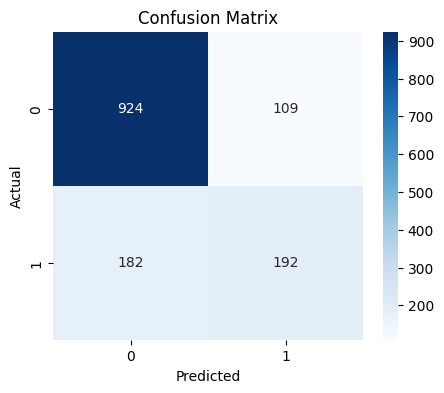

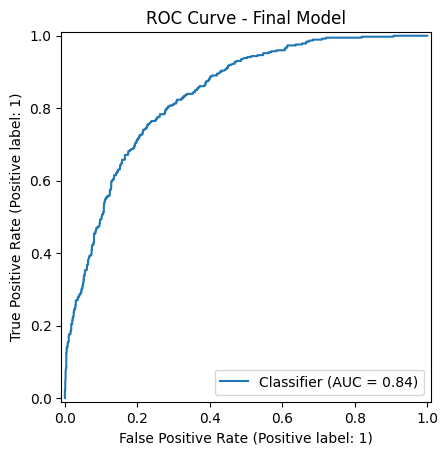

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.64      0.51      0.57       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.72      1407
weighted avg       0.78      0.79      0.79      1407



In [ ]:
#  14.1 Classification Metrics

accuracy = accuracy_score(y_test, y_pred_final)
precision = precision_score(y_test, y_pred_final)
recall = recall_score(y_test, y_pred_final)
f1 = f1_score(y_test, y_pred_final)
roc_auc = roc_auc_score(y_test, y_prob_final)

print("Final Model Performance")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC:", roc_auc)


# 14.2 Confusion Matrix

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# 14.3 ROC Curve

RocCurveDisplay.from_predictions(y_test, y_prob_final)
plt.title("ROC Curve - Final Model")
plt.show()


# 14.4 Classification Report

print("Classification Report:")
print(classification_report(y_test, y_pred_final))

The tuned Gradient Boosting model has been tested with the unseen test set based on various measures of classification. The model was able to predict the churn status of approximately 79 percent of the customers, which means that it was accurate to a key of 0.79. Precision score, which is 0.64 indicates that as the model predicts churn, roughly 64 out of such predictions are accurate. The recall result of 0.51 shows that the model is able to target approximately fifty one percent of the customers who actually churn. The F1-score of 0.57 is obtained between the balance between precision and recall. The ROC-AUC of 0.84 indicates a presence of high capacity to between customers who are churned and those who are non-churned.

The confusion matrix gives further details. The model was right in 924 non-churn customers (true negatives) and 192 churned customers (true positives). Nevertheless, 109 customers had been misclassified as churners (false positives) and 182 churned customers had been overlooked (false negatives). False negatives are of concern especially when it involves churn prediction since such customers abandon the service without prior notification.

There is a good separation between the two classes in the ROC curve, which validates the fact that the model is able to rank the customers according to the probability of churning. These findings are further supported in the classification report with greater performance in prediction to retained customers compared to customers that are churned (Yuan and Liu, 2025).

# Step 15 — Feature Importance and Model Explainability

Top 10 Important Features:
                                Feature  Importance
36         cat__Contract_Month-to-month    0.420114
0                           num__tenure    0.125382
2                     num__TotalCharges    0.086558
16     cat__InternetService_Fiber optic    0.083985
18               cat__OnlineSecurity_No    0.073004
1                   num__MonthlyCharges    0.064106
27                  cat__TechSupport_No    0.045803
43  cat__PaymentMethod_Electronic check    0.036780
21                 cat__OnlineBackup_No    0.010843
12                cat__MultipleLines_No    0.010303


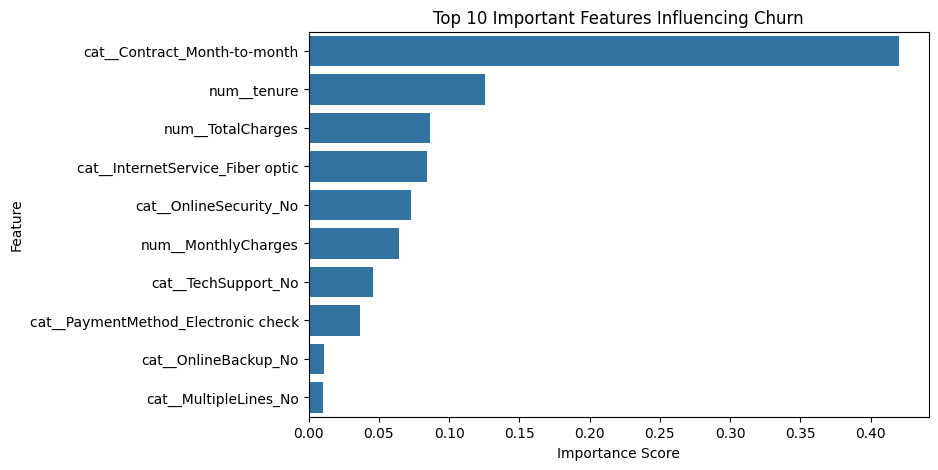

In [ ]:
# Extract trained Gradient Boosting model
model = final_model.named_steps['model']

# Get feature names after preprocessing
encoded_features = final_model.named_steps['preprocessor'].get_feature_names_out()

# Extract feature importances
feature_importances = model.feature_importances_

# Create DataFrame
importance_df = pd.DataFrame({
    "Feature": encoded_features,
    "Importance": feature_importances
})

# Sort features by importance
importance_df = importance_df.sort_values(by="Importance", ascending=False)

# Display top 10 important features
top_features = importance_df.head(10)
print("Top 10 Important Features:")
print(top_features)

# Plot feature importance
plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=top_features)
plt.title("Top 10 Important Features Influencing Churn")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

# Business Discussion and Recommendations

## 1 Strengths of the Solution

The suggested machine learning error is based on the data about the accounts of customers and their billing which is already stored in the operational systems of the telecom companies. This is what makes the approach feasible since no further data collection is necessary. The model can be used to identify potential customers who have high chances of leaving the service before the service is churned. This contributes to early intervention in the way of retention campaigns. Through the attention of high risks customers, the companies can spare revenue loss and enhance the retention strategy among customers.

## 2 Limitations

The dataset lacks a number of factors that can impact on churn behaviour. Indicatively, customer complaints, service downtimes, and quality of networks are not mentioned. The data also does not involve competitor pricing and offers. Since the model is based solely on the trends in historical data, it might not capture all externalities that influence the decision of customers.

## 3 Business Implications

The analysis shows that the customers on monthly contracts are quicker to churn as compared to customers on long term contracts. The churn risk is also observed to be very high among customers whose monthly charges are higher. Moreover, a customer who is not under technical support services seems to be more likely to quit the company.

## 4 Recommendations

The retention efforts should target those customers who have month-to-month contracts as they are the group with the worst churn risk. The issue of incentives given to customers to convert to one-year or two-year contracts can lower the churn rates. Another way in which companies can enhance retention is to include technical support services with internet packages. Short-term customer loyalty could be used to enhance initial interaction and minimize initial churn.

## 5 Explainability

The Gradient Boosting model also offers feature importance scores which can be used to determine the most active features of churn. This will enable the managers to know customer attributes that have the most significant impact on churn risk. In spite of the fact that tree-based ensemble models are less transparent than simple linear models, the importance of features still provides a useful insight into decision drivers.

## 6 Deployment Decision

The model may be implemented as a decision-support system to use by teams of customer retention. Rather than automatic decisions it can be utilized to mark customers who look high probability of churn. These predictions can then be checked by the customer service or marketing teams and specific retention strategies can be undertaken (Zhang, 2025).

# Conclusion

This project designed a fully built machine learning pipeline to forecast a churn among customers in a telecommunications company. The idea was to see the customers who are most likely to relinquish the service in order to take preemptive measures and enhance retention of the customer. The project was organized into a coherent workflow, i.e., it involved formulating the problem, exploring the data to verify its structure, cleaning it, feature engineering, training a model, tuning the hyperparameters, and making the final evaluation with unseen test data.

In the process of exploratory analysis of data, a number of meaningful trends were located within the customer behaviour. Those customers who had shorter tenure were more likely to churn so that the earlier the customers are engaged the more significance it has on retention. The churn rates were considerably higher when customers are on monthly contracts than when they are on annual and long-term contracts. Also, an increase in monthly fees and lack of technical support services were linked to the risk of churn.

A number of machine learning models were trained and compared, namely the following, Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting. The tuned Gradient Boosting model reported the best overall predictive performance of these models. The model was found to be quite accurate and has a high ROC-AUC score, and this shows that the model is good at pre-empting churning customers as well as stayers.

The analysis on the importance of features further emphasized the major variables that had a role to play in churn behaviour. The most influential characteristics included the type of contract, the duration of working with the customer, monthly fee, total fees, and availability of technical support. Such insights have valuable data that can assist telecom firms to know why customers are dissatisfied and terminating the services.

Generally, the churn prediction model is developed and can be applied to help telecom companies to recognise high-risk customers before hand. These predictions aid in companies developing specific retention programs like upgrading the contract, offering better customer support services, or having loyalty incentives. These proactive measures can minimize the churn rate, enhance customer satisfaction, and bolster the long-term relationships with these customers.

# Reference list
* Aggarwal, A., Taneja, P., Seth, K. and Singh Pannu, H. (2025). Predicting Telecom Customer Churn Utilising Machine Learning Models. 2025 World Skills Conference on Universal Data Analytics and Sciences (WorldSUAS), [online] pp.1–6. doi:https://doi.org/10.1109/worldsuas66815.2025.11198977.
* Aldalan, A.M. and Almaleh, A. (2023). Customer Churn Prediction Using Four Machine Learning Algorithms Integrating Feature Selection and Normalization in the Telecom Sector. International Conference on Telecommunications and Data Communications. [online] Available at: https://www.researchgate.net/publication/369113771_Customer_Churn_Prediction_Using_Four_Machine_Learning_Algorithms_Integrating_Feature_Selection_and_Normalization_in_the_Telecom_Sector [Accessed 14 Mar. 2026].
* Alotaibi, M.Z. and Haq, M.A. (2024). Customer Churn Prediction for Telecommunication Companies using Machine Learning and Ensemble Methods. Engineering Technology & Applied Science Research, [online] 14(3), pp.14572–14578. doi:https://doi.org/10.48084/etasr.7480.
* Deepika Kumari, Santosh Kumar Singh, Sanjay Subhash Katira, Inumarthi V Srinivas and Uday Salunkhe (2025). Telecom Customer Churn Forecasting Using Machine Learning: A Data-Driven Predictive Framework. Metallurgical and Materials Engineering, [online] 31(4), pp.922–929. doi:https://doi.org/10.63278/1536.
* Demir, B. and Öztürk Ergün, Ö. (2025). Customer Churn Prediction with Machine Learning Methods In Telecommunication Industry. Advances in Artificial Intelligence Research, [online] 5(1), pp.32–41. doi:https://doi.org/10.54569/aair.1709274.
* Sam, G., Asuquo, P. and Stephen, B. (2024). Customer Churn Prediction using Machine Learning Models. Journal of Engineering Research and Reports, [online] 26(2), pp.181–193. doi:https://doi.org/10.9734/jerr/2024/v26i21081.Shoja, H., Sabet, E. and Sadat, S.S. (2026). Customer Churn Prediction System Using Machine Learning: A Case Study ROSHAN Telecom-Afghanistan. International Journal of Integrated Science and Technology, [online] 4(2), pp.123–137. doi:https://doi.org/10.59890/ijist.v4i2.287.
* Yuan, J. and Liu, H. (2025). Telecom Customer Churn Prediction with Explainable Machine Learning. [online] pp.246–250. doi:https://doi.org/10.1145/3757110.3757152.
* Zhang, Y. (2025). Machine Learning-Based Prediction of Telecom Customer Churn: Comparative Model Analysis. Academic Journal of Science and Technology, [online] 18(2), pp.116–123. doi:https://doi.org/10.54097/9r12cm81.

# Appendix

Dataset Link: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

GitHub Link: https://github.com/harjot37/telco-customer-churn-ml-pipeline